In [1]:
# ============================================
# AI/ML-Based Predictive Maintenance
# Vehicle Health Monitoring System
# STEP 1: Generate Synthetic Dataset
# ============================================

import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# Number of vehicle records
n = 10000

# --------------------------------------------
# 1. Generate vehicle sensor parameters
# --------------------------------------------

engine_temperature = np.random.normal(90, 12, n)

rpm = np.random.normal(2200, 500, n)
rpm = np.clip(rpm, 800, 4500)

oil_pressure = np.random.normal(45, 8, n)
oil_pressure = np.clip(oil_pressure, 15, 65)

vibration = np.random.gamma(shape=2.0, scale=1.2, size=n)
vibration = np.clip(vibration, 0.1, 10)

battery_voltage = np.random.normal(12.5, 0.7, n)
battery_voltage = np.clip(battery_voltage, 10, 14.5)

coolant_temperature = np.random.normal(88, 10, n)
coolant_temperature = np.clip(coolant_temperature, 60, 120)

fuel_consumption = np.random.normal(7.5, 2, n)
fuel_consumption = np.clip(fuel_consumption, 2, 15)

vehicle_speed = np.random.normal(55, 20, n)
vehicle_speed = np.clip(vehicle_speed, 0, 120)

operating_hours = np.random.uniform(100, 5000, n)

# --------------------------------------------
# 2. Create a failure risk score
# --------------------------------------------

risk_score = (
    0.25 * (engine_temperature > 105) +
    0.20 * (oil_pressure < 30) +
    0.25 * (vibration > 4) +
    0.10 * (battery_voltage < 11.5) +
    0.15 * (coolant_temperature > 100) +
    0.10 * (fuel_consumption > 11) +
    0.10 * (rpm > 3500) +
    0.10 * (operating_hours > 4000)
)

# Add a small amount of randomness
risk_score += np.random.normal(0, 0.08, n)

# Convert risk score into failure probability
failure_probability = 1 / (1 + np.exp(-8 * (risk_score - 0.45)))

# Generate failure label
failure = (failure_probability >= 0.5).astype(int)

# --------------------------------------------
# 3. Create DataFrame
# --------------------------------------------

df = pd.DataFrame({
    "Engine_Temperature": engine_temperature,
    "RPM": rpm,
    "Oil_Pressure": oil_pressure,
    "Vibration": vibration,
    "Battery_Voltage": battery_voltage,
    "Coolant_Temperature": coolant_temperature,
    "Fuel_Consumption": fuel_consumption,
    "Vehicle_Speed": vehicle_speed,
    "Operating_Hours": operating_hours,
    "Failure": failure
})

# --------------------------------------------
# 4. Display dataset
# --------------------------------------------

print("Dataset generated successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head(10))

Dataset generated successfully!
Number of rows: 10000
Number of columns: 10


,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours,Failure
0,95.960570,1860.752635,47.786290,0.233313,13.015493,94.181571,8.074652,42.551505,4604.752738,0
1,88.340828,2047.250268,47.266589,0.770398,12.299844,85.719328,4.536646,52.534088,3487.318571,0
2,97.772262,1901.309469,37.507841,4.043172,12.964519,89.500855,5.347899,21.986361,1250.681670,0
3,108.276358,2255.209023,49.636674,3.279595,12.145282,92.199916,4.203692,48.378007,3529.604741,0
4,87.190160,2798.589266,33.079339,2.120669,11.849365,78.913919,9.909231,28.783284,3530.188938,0
5,87.190357,1814.478921,39.766525,1.620671,12.330782,103.194009,8.736672,66.971047,4629.550631,0
6,108.950554,2700.410249,29.007297,0.692978,12.850667,90.241212,9.707988,46.302174,1355.958825,1
7,99.209217,1809.163964,57.469012,1.438460,12.585539,89.416076,10.740539,48.927757,4849.835068,0
8,84.366307,1776.186394,43.147604,0.538111,11.930840,79.333073,8.378486,46.641308,3457.305011,0
9,96.510721,2609.297309,62.335072,3.263898,13.760360,99.697425,7.379837,72.967877,1659.806410,0


In [3]:


print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFailure Distribution:")
print(df["Failure"].value_counts())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(10000, 10)

Column Names:
['Engine_Temperature', 'RPM', 'Oil_Pressure', 'Vibration', 'Battery_Voltage', 'Coolant_Temperature', 'Fuel_Consumption', 'Vehicle_Speed', 'Operating_Hours', 'Failure']

Missing Values:
Engine_Temperature     0
RPM                    0
Oil_Pressure           0
Vibration              0
Battery_Voltage        0
Coolant_Temperature    0
Fuel_Consumption       0
Vehicle_Speed          0
Operating_Hours        0
Failure                0
dtype: int64

Failure Distribution:
Failure
0    9609
1     391
Name: count, dtype: int64

Statistical Summary:


,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours,Failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,89.974368,2207.242611,44.888083,2.368037,12.499945,88.175180,7.492651,55.222680,2543.752308,0.039100
std,12.041549,499.052035,7.896573,1.682239,0.707506,9.936881,2.000088,20.029362,1422.801940,0.193843
min,42.931197,800.000000,15.759308,0.100000,10.105034,60.000000,2.000000,0.000000,100.134897,0.000000
25%,81.928914,1868.994548,39.398785,1.119601,12.027579,81.362999,6.127666,42.061837,1302.579658,0.000000
50%,89.968860,2207.923358,44.953854,1.958867,12.507097,88.239273,7.476622,55.188255,2531.828871,0.000000
75%,98.052971,2546.932435,50.311179,3.206088,12.978223,94.908820,8.842879,68.514876,3780.614183,0.000000
max,137.114852,4439.542126,65.000000,10.000000,14.500000,120.000000,15.000000,120.000000,4999.326549,1.000000


In [4]:
# Save dataset as CSV

df.to_csv("vehicle_predictive_maintenance_dataset.csv", index=False)

print("Dataset saved successfully!")


Dataset saved successfully!


In [5]:
from google.colab import files

files.download("vehicle_predictive_maintenance_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 10)

First 5 rows:


,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours,Failure
0,95.960570,1860.752635,47.786290,0.233313,13.015493,94.181571,8.074652,42.551505,4604.752738,0
1,88.340828,2047.250268,47.266589,0.770398,12.299844,85.719328,4.536646,52.534088,3487.318571,0
2,97.772262,1901.309469,37.507841,4.043172,12.964519,89.500855,5.347899,21.986361,1250.681670,0
3,108.276358,2255.209023,49.636674,3.279595,12.145282,92.199916,4.203692,48.378007,3529.604741,0
4,87.190160,2798.589266,33.079339,2.120669,11.849365,78.913919,9.909231,28.783284,3530.188938,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Engine_Temperature   10000 non-null  float64
 1   RPM                  10000 non-null  float64
 2   Oil_Pressure         10000 non-null  float64
 3   Vibration            10000 non-null  float64
 4   Battery_Voltage      10000 non-null  float64
 5   Coolant_Temperature  10000 non-null  float64
 6   Fuel_Consumption     10000 non-null  float64
 7   Vehicle_Speed        10000 non-null  float64
 8   Operating_Hours      10000 non-null  float64
 9   Failure              10000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 781.4 KB


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Engine_Temperature     0
RPM                    0
Oil_Pressure           0
Vibration              0
Battery_Voltage        0
Coolant_Temperature    0
Fuel_Consumption       0
Vehicle_Speed          0
Operating_Hours        0
Failure                0
dtype: int64


Failure distribution:
Failure
0    9609
1     391
Name: count, dtype: int64


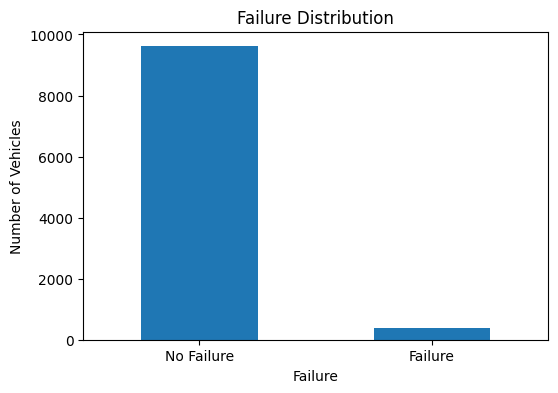

In [8]:
import matplotlib.pyplot as plt

print("Failure distribution:")
print(df["Failure"].value_counts())

plt.figure(figsize=(6, 4))

df["Failure"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Failure")
plt.ylabel("Number of Vehicles")
plt.title("Failure Distribution")
plt.xticks([0, 1], ["No Failure", "Failure"], rotation=0)

plt.show()

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Engine_Temperature,10000.0,89.974368,12.041549,42.931197,81.928914,89.968860,98.052971,137.114852
RPM,10000.0,2207.242611,499.052035,800.000000,1868.994548,2207.923358,2546.932435,4439.542126
Oil_Pressure,10000.0,44.888083,7.896573,15.759308,39.398785,44.953854,50.311179,65.000000
Vibration,10000.0,2.368037,1.682239,0.100000,1.119601,1.958867,3.206088,10.000000
Battery_Voltage,10000.0,12.499945,0.707506,10.105034,12.027579,12.507097,12.978223,14.500000
Coolant_Temperature,10000.0,88.175180,9.936881,60.000000,81.362999,88.239273,94.908820,120.000000
Fuel_Consumption,10000.0,7.492651,2.000088,2.000000,6.127666,7.476622,8.842879,15.000000
Vehicle_Speed,10000.0,55.222680,20.029362,0.000000,42.061837,55.188255,68.514876,120.000000
Operating_Hours,10000.0,2543.752308,1422.801940,100.134897,1302.579658,2531.828871,3780.614183,4999.326549
Failure,10000.0,0.039100,0.193843,0.000000,0.000000,0.000000,0.000000,1.000000


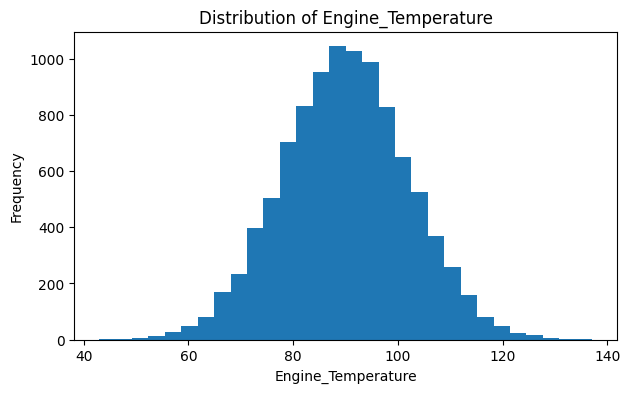

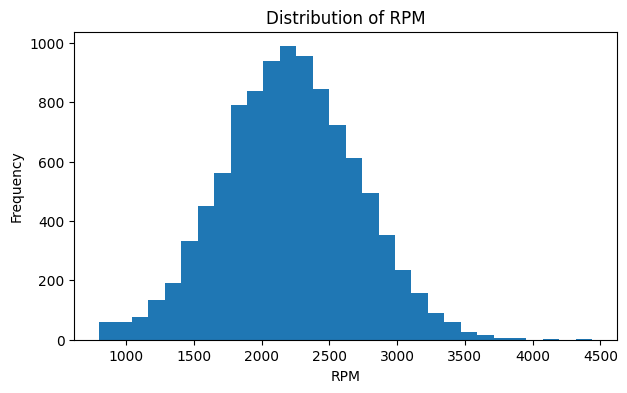

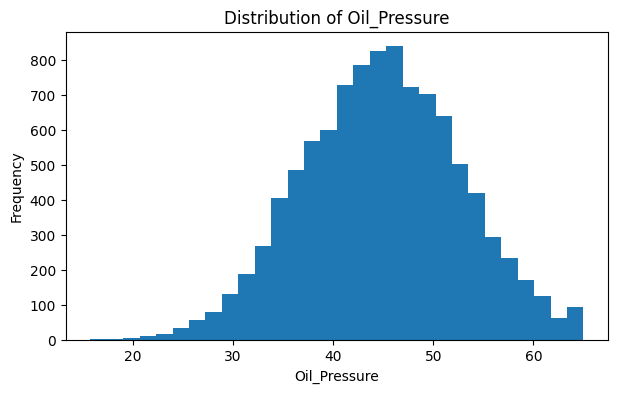

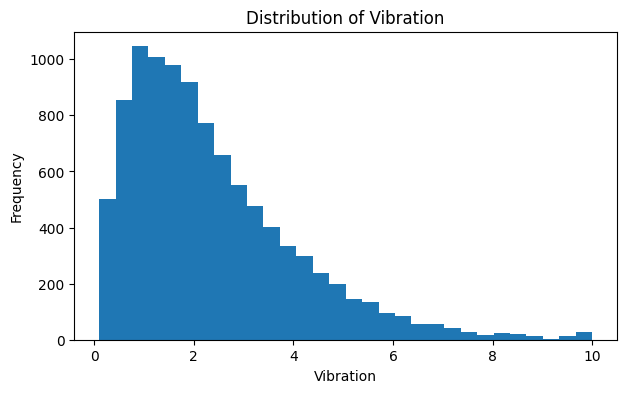

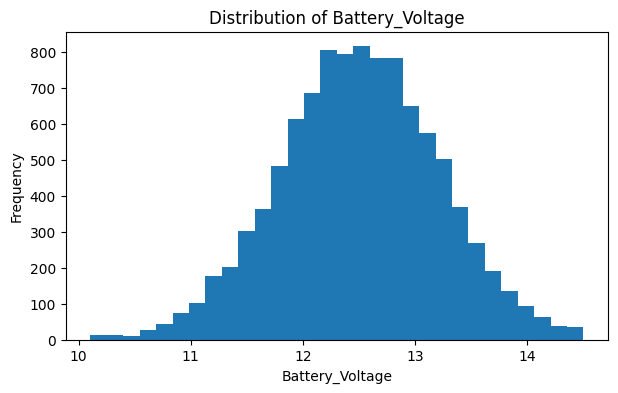

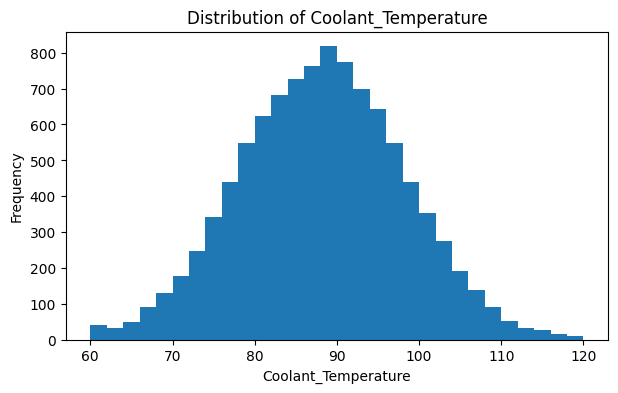

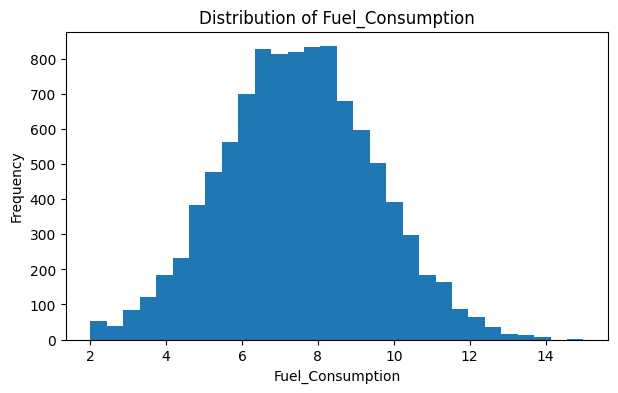

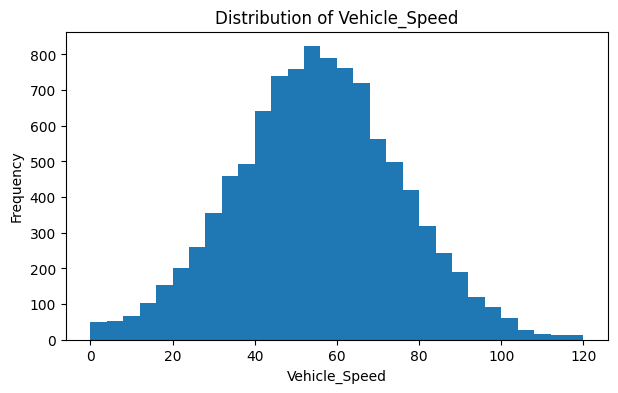

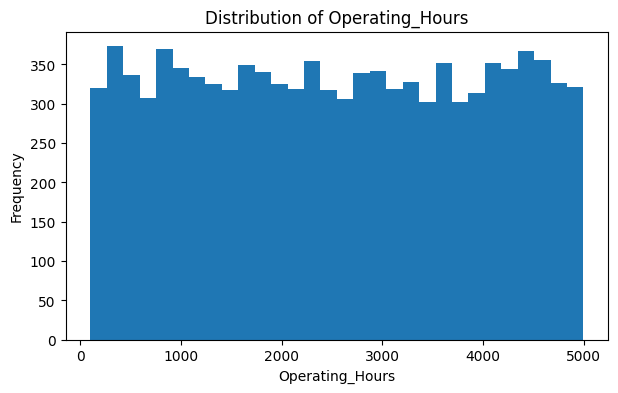

In [10]:
sensor_columns = [
    "Engine_Temperature",
    "RPM",
    "Oil_Pressure",
    "Vibration",
    "Battery_Voltage",
    "Coolant_Temperature",
    "Fuel_Consumption",
    "Vehicle_Speed",
    "Operating_Hours"
]

for column in sensor_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=30)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.show()

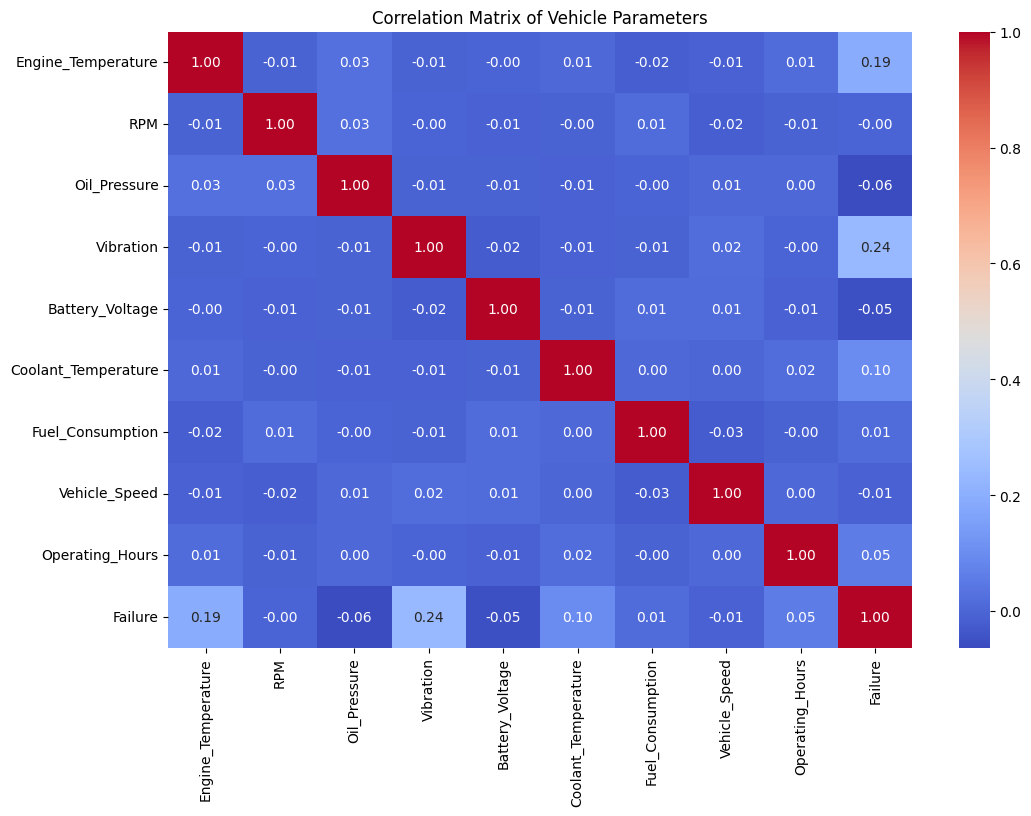

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Vehicle Parameters")

plt.show()

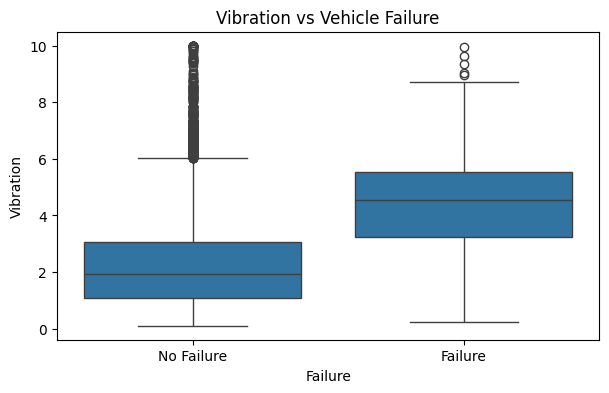

In [12]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x="Failure",
    y="Vibration",
    data=df
)

plt.xlabel("Failure")
plt.ylabel("Vibration")
plt.title("Vibration vs Vehicle Failure")
plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

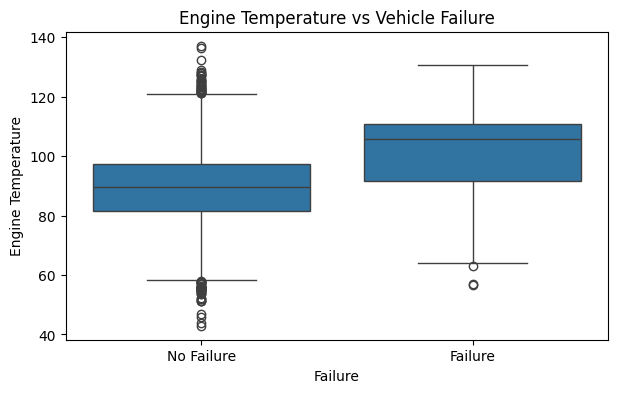

In [13]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x="Failure",
    y="Engine_Temperature",
    data=df
)

plt.xlabel("Failure")
plt.ylabel("Engine Temperature")
plt.title("Engine Temperature vs Vehicle Failure")
plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

In [14]:
# ============================================
# STEP 3: DATA PREPROCESSING
# ============================================

# Input features specified by the project
features = [
    "Engine_Temperature",
    "RPM",
    "Oil_Pressure",
    "Vibration",
    "Battery_Voltage",
    "Coolant_Temperature",
    "Fuel_Consumption",
    "Vehicle_Speed",
    "Operating_Hours"
]

# Target variable
target = "Failure"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Engine_Temperature', 'RPM', 'Oil_Pressure', 'Vibration', 'Battery_Voltage', 'Coolant_Temperature', 'Fuel_Consumption', 'Vehicle_Speed', 'Operating_Hours']

Target:
Failure

X shape: (10000, 9)
y shape: (10000,)


In [15]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
Failure
0    9609
1     391
Name: count, dtype: int64

Target percentage:
Failure
0    96.09
1     3.91
Name: proportion, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 9)
Testing data: (2000, 9)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (8000, 9)
Scaled testing data shape: (2000, 9)


In [18]:
print("Mean of scaled features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_train_scaled.std(axis=0))

Mean of scaled features:
[-1.10400578e-15 -8.84403661e-16 -8.28670466e-16  7.10542736e-18
 -9.93871652e-16  5.63105118e-16 -1.80300219e-16  5.15143483e-17
  1.13242749e-16]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [19]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

display(X_train_scaled_df.head())

,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours
1163,-1.638422,2.349338,-0.895149,-0.256878,1.528642,-1.729770,0.713658,-0.023824,1.049458
796,-0.034316,-1.919041,-1.991014,-0.496864,0.844238,0.079575,-0.619851,0.404772,1.144037
7944,0.416317,1.548527,1.298006,0.644529,-0.283590,0.292834,-0.851623,0.942387,0.189596
1219,2.148024,-0.396591,0.136706,-0.228729,-2.377396,-0.401856,-0.905573,1.231920,-1.140060
1380,0.682389,0.466363,-0.121398,0.497143,0.767166,-1.273839,-1.034862,0.398117,1.580552


In [20]:
# ============================================
# STEP 4: LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [22]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred_lr[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [23]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Failure probabilities:")
print(y_prob_lr[:10])

Failure probabilities:
[0.04027434 0.01315265 0.00275821 0.00195149 0.05116443 0.02990656
 0.04004027 0.00039078 0.02353814 0.01726641]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
--------------------------------
Accuracy : 0.9605
Precision: 0.4666666666666667
Recall   : 0.08974358974358974
F1 Score : 0.15053763440860216


In [25]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1922
           1       0.47      0.09      0.15        78

    accuracy                           0.96      2000
   macro avg       0.72      0.54      0.57      2000
weighted avg       0.94      0.96      0.95      2000



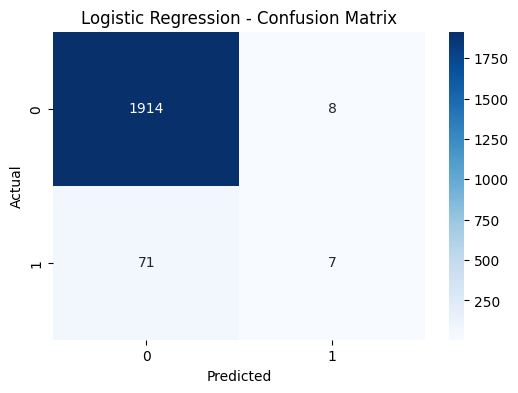

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [27]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9605,0.466667,0.089744,0.150538


In [28]:
# ============================================
# STEP 5: DECISION TREE
# ============================================

from sklearn.tree import DecisionTreeClassifier

In [29]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [30]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Predictions:")
print(y_pred_dt[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Failure probabilities:")
print(y_prob_dt[:10])

Failure probabilities:
[0.   0.   0.   0.   0.   0.   0.   0.25 0.25 0.  ]


In [32]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
--------------------------------
Accuracy : 0.967
Precision: 0.6428571428571429
Recall   : 0.34615384615384615
F1 Score : 0.45


In [33]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1922
           1       0.64      0.35      0.45        78

    accuracy                           0.97      2000
   macro avg       0.81      0.67      0.72      2000
weighted avg       0.96      0.97      0.96      2000



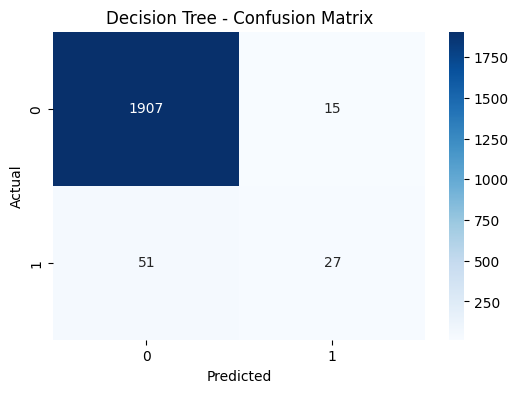

In [34]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [35]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9605,0.466667,0.089744,0.150538
1,Decision Tree,0.9670,0.642857,0.346154,0.450000


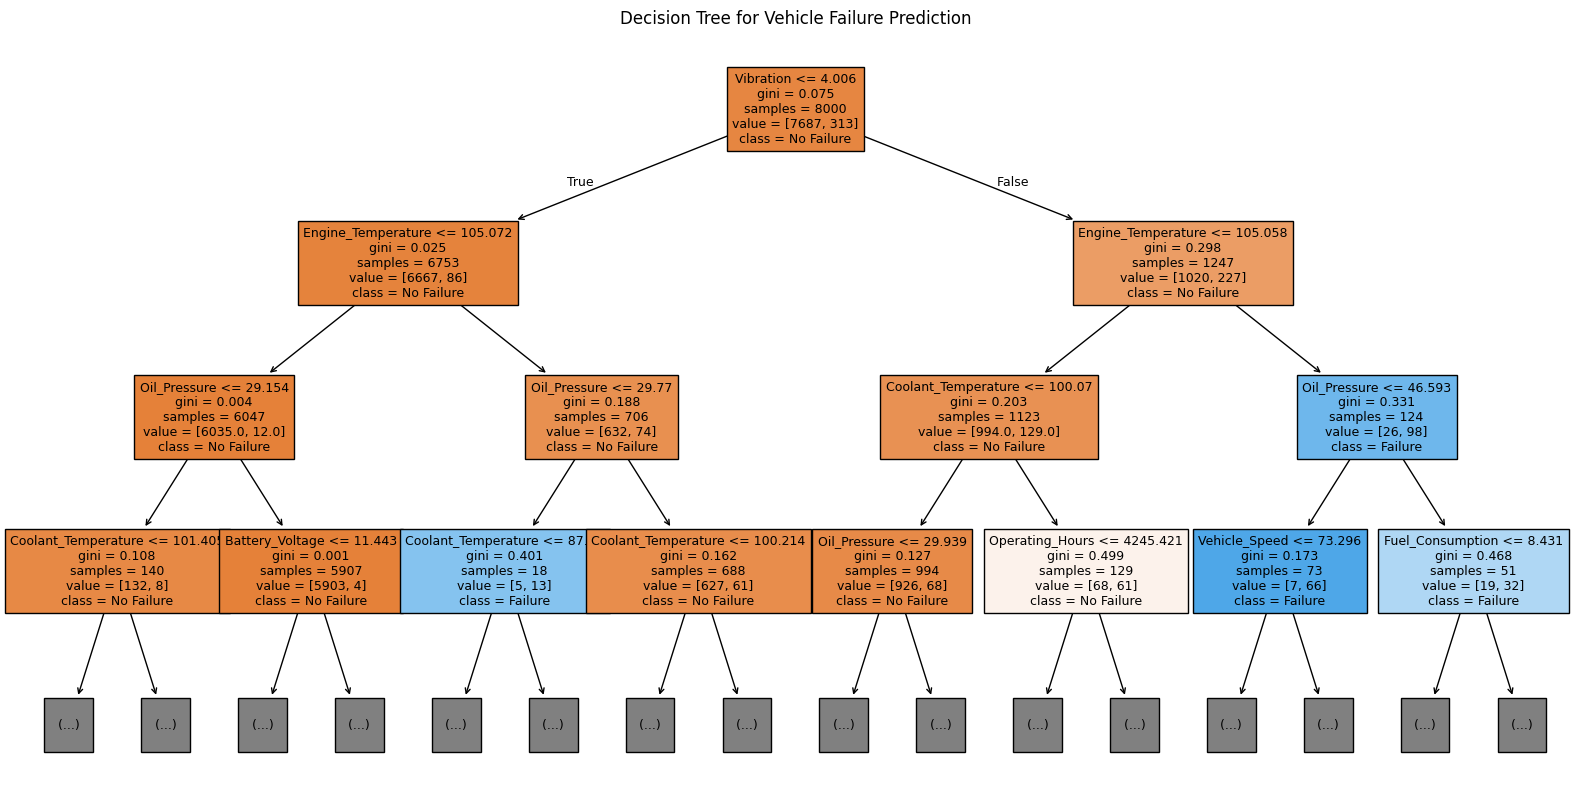

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=features,
    class_names=["No Failure", "Failure"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree for Vehicle Failure Prediction")
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]


In [38]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
--------------------------------
Accuracy : 0.974
Precision: 0.782608695652174
Recall   : 0.46153846153846156
F1 Score : 0.5806451612903226

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1922
           1       0.78      0.46      0.58        78

    accuracy                           0.97      2000
   macro avg       0.88      0.73      0.78      2000
weighted avg       0.97      0.97      0.97      2000



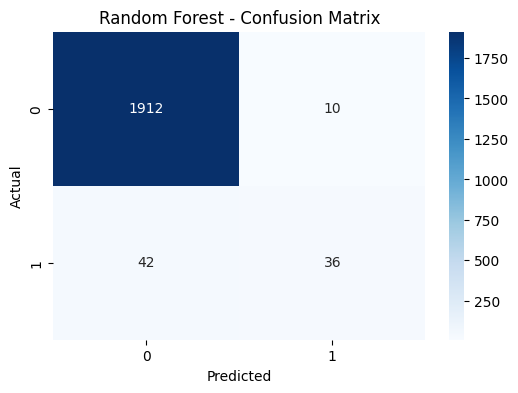

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [40]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
3,Vibration,0.240483
0,Engine_Temperature,0.221588
5,Coolant_Temperature,0.121506
2,Oil_Pressure,0.108313
8,Operating_Hours,0.082064
4,Battery_Voltage,0.071045
6,Fuel_Consumption,0.054983
1,RPM,0.050599
7,Vehicle_Speed,0.049420


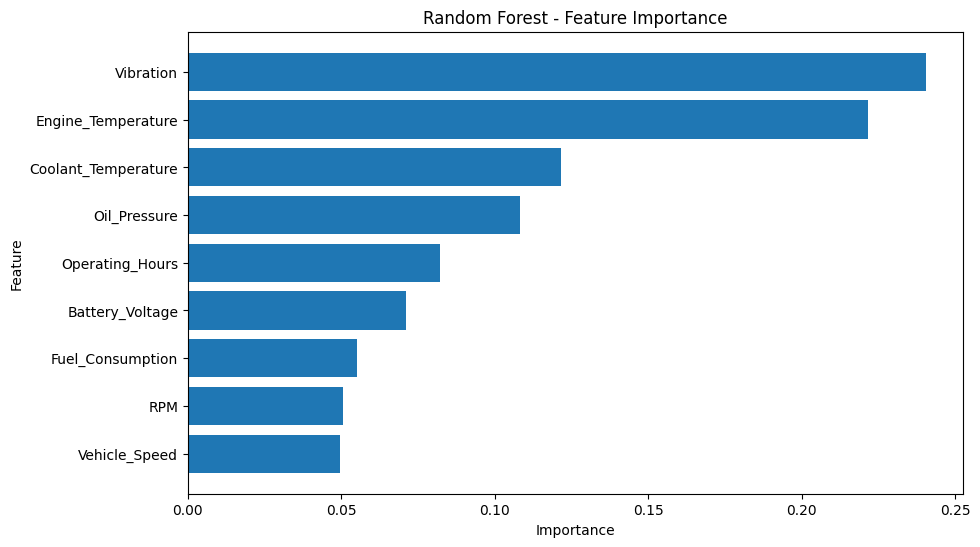

In [41]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [42]:
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9605,0.466667,0.089744,0.150538
1,Decision Tree,0.9670,0.642857,0.346154,0.450000
2,Random Forest,0.9740,0.782609,0.461538,0.580645


In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [44]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("--------------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
--------------------------------
Accuracy : 0.9735
Precision: 0.7777777777777778
Recall   : 0.44871794871794873
F1 Score : 0.5691056910569106

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1922
           1       0.78      0.45      0.57        78

    accuracy                           0.97      2000
   macro avg       0.88      0.72      0.78      2000
weighted avg       0.97      0.97      0.97      2000



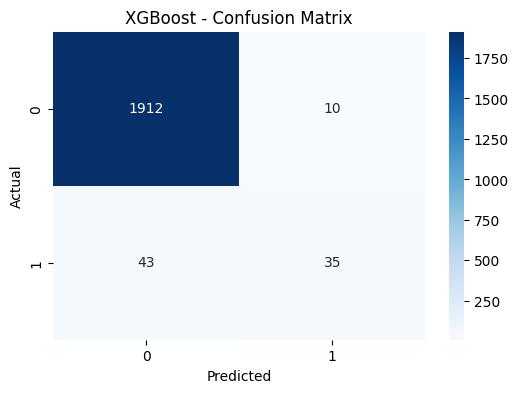

In [45]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()

In [46]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance)

,Feature,Importance
3,Vibration,0.294313
0,Engine_Temperature,0.250350
5,Coolant_Temperature,0.117315
2,Oil_Pressure,0.090951
8,Operating_Hours,0.066701
4,Battery_Voltage,0.061313
6,Fuel_Consumption,0.048560
7,Vehicle_Speed,0.036321
1,RPM,0.034175


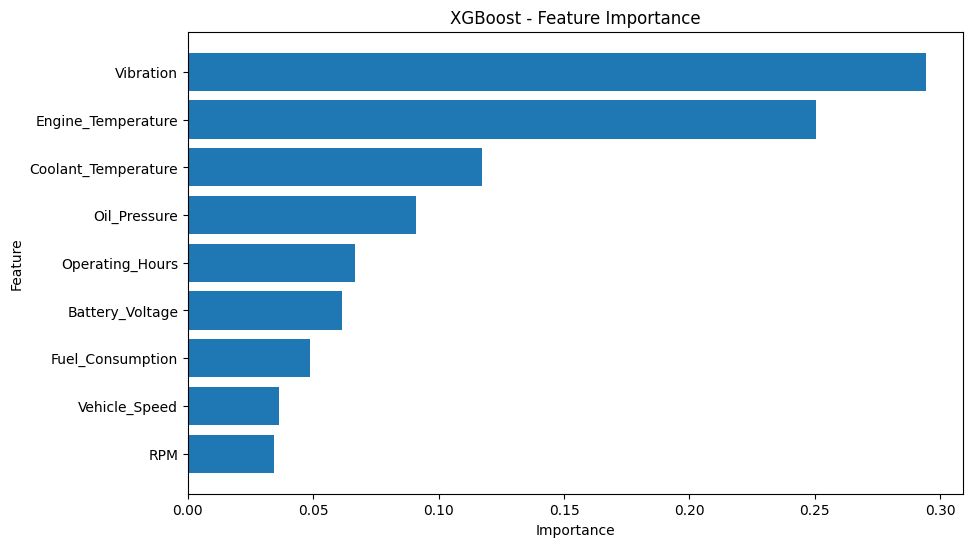

In [47]:
plt.figure(figsize=(10,6))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost - Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [48]:
results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9605,0.466667,0.089744,0.150538
1,Decision Tree,0.9670,0.642857,0.346154,0.450000
2,Random Forest,0.9740,0.782609,0.461538,0.580645
3,XGBoost,0.9735,0.777778,0.448718,0.569106


In [49]:
import numpy as np

sequence_length = 10

X_lstm = []
y_lstm = []

data = X.values
labels = y.values

for i in range(len(data) - sequence_length):
    X_lstm.append(data[i:i + sequence_length])
    y_lstm.append(labels[i + sequence_length])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("LSTM Input Shape :", X_lstm.shape)
print("LSTM Target Shape:", y_lstm.shape)

LSTM Input Shape : (9990, 10, 9)
LSTM Target Shape: (9990,)


In [50]:
train_size = int(0.8 * len(X_lstm))

X_lstm_train = X_lstm[:train_size]
X_lstm_test = X_lstm[train_size:]

y_lstm_train = y_lstm[:train_size]
y_lstm_test = y_lstm[train_size:]

print("Training Data:", X_lstm_train.shape)
print("Testing Data :", X_lstm_test.shape)

Training Data: (7992, 10, 9)
Testing Data : (1998, 10, 9)


In [51]:
from sklearn.preprocessing import StandardScaler

lstm_scaler = StandardScaler()

X_lstm_train_2d = X_lstm_train.reshape(-1, X_lstm_train.shape[2])

lstm_scaler.fit(X_lstm_train_2d)

X_lstm_train_scaled = lstm_scaler.transform(
    X_lstm_train_2d
).reshape(X_lstm_train.shape)

X_lstm_test_2d = X_lstm_test.reshape(-1, X_lstm_test.shape[2])

X_lstm_test_scaled = lstm_scaler.transform(
    X_lstm_test_2d
).reshape(X_lstm_test.shape)

print("Scaled Training Shape:", X_lstm_train_scaled.shape)
print("Scaled Testing Shape :", X_lstm_test_scaled.shape)

Scaled Training Shape: (7992, 10, 9)
Scaled Testing Shape : (1998, 10, 9)


In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [53]:
lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(
            X_lstm_train_scaled.shape[1],
            X_lstm_train_scaled.shape[2]
        ),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = lstm_model.fit(
    X_lstm_train_scaled,
    y_lstm_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9571 - loss: 0.2290 - val_accuracy: 0.9543 - val_loss: 0.1863
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9615 - loss: 0.1700 - val_accuracy: 0.9543 - val_loss: 0.1876
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9615 - loss: 0.1707 - val_accuracy: 0.9543 - val_loss: 0.1875
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9615 - loss: 0.1669 - val_accuracy: 0.9543 - val_loss: 0.1875
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9615 - loss: 0.1660 - val_accuracy: 0.9543 - val_loss: 0.1894
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9615 - loss: 0.1669 - val_accuracy: 0.9543 - val_loss: 0.1893
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9615 - loss: 0.1657 - val_accuracy: 0.9543 - val_loss: 0.1944
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9615 - loss: 0.1647 - val_accuracy

In [55]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_lstm_test_scaled,
    y_lstm_test,
    verbose=0
)

print("LSTM Results")
print("--------------------------------")
print("Test Loss     :", lstm_loss)
print("Test Accuracy :", lstm_accuracy)

LSTM Results
--------------------------------
Test Loss     : 0.16637484729290009
Test Accuracy : 0.9644644856452942


In [56]:
y_prob_lstm = lstm_model.predict(
    X_lstm_test_scaled
).flatten()

y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [57]:
lstm_precision = precision_score(y_lstm_test, y_pred_lstm)
lstm_recall = recall_score(y_lstm_test, y_pred_lstm)
lstm_f1 = f1_score(y_lstm_test, y_pred_lstm)

print("LSTM Classification Results")
print("--------------------------------")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)

print("\nClassification Report:")
print(classification_report(y_lstm_test, y_pred_lstm))

LSTM Classification Results
--------------------------------
Accuracy : 0.9644644856452942
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1927
           1       0.00      0.00      0.00        71

    accuracy                           0.96      1998
   macro avg       0.48      0.50      0.49      1998
weighted avg       0.93      0.96      0.95      1998



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

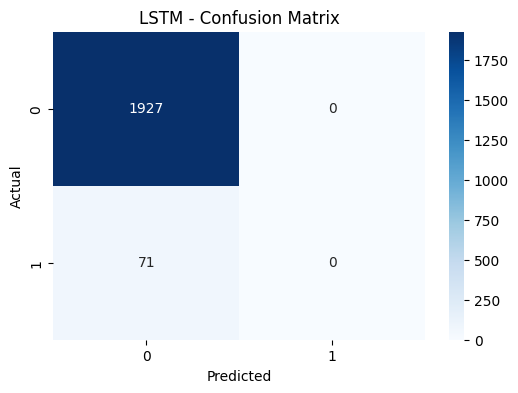

In [58]:
cm_lstm = confusion_matrix(
    y_lstm_test,
    y_pred_lstm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM - Confusion Matrix")

plt.show()

In [59]:
results.append({
    "Model": "LSTM",
    "Accuracy": lstm_accuracy,
    "Precision": lstm_precision,
    "Recall": lstm_recall,
    "F1 Score": lstm_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.960500,0.466667,0.089744,0.150538
1,Decision Tree,0.967000,0.642857,0.346154,0.450000
2,Random Forest,0.974000,0.782609,0.461538,0.580645
3,XGBoost,0.973500,0.777778,0.448718,0.569106
4,LSTM,0.964464,0.000000,0.000000,0.000000


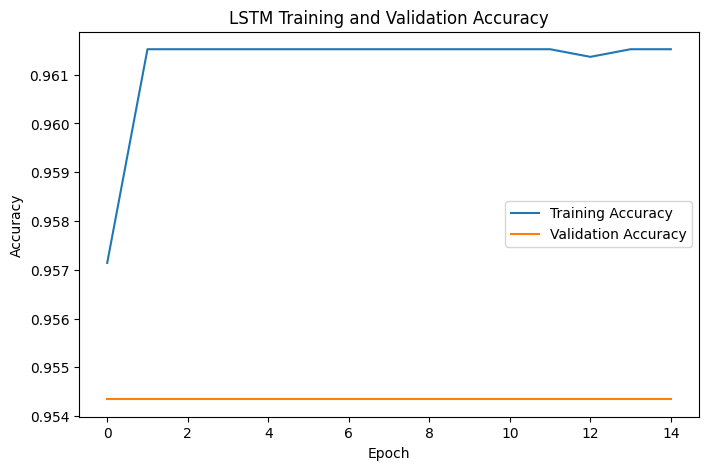

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()

plt.show()


In [61]:
from tensorflow.keras.layers import GRU

In [62]:
gru_model = Sequential([
    GRU(
        64,
        input_shape=(
            X_lstm_train_scaled.shape[1],
            X_lstm_train_scaled.shape[2]
        ),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
gru_history = gru_model.fit(
    X_lstm_train_scaled,
    y_lstm_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9443 - loss: 0.2330 - val_accuracy: 0.9543 - val_loss: 0.2022
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9615 - loss: 0.1742 - val_accuracy: 0.9543 - val_loss: 0.1877
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9615 - loss: 0.1699 - val_accuracy: 0.9543 - val_loss: 0.1904
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9615 - loss: 0.1712 - val_accuracy: 0.9543 - val_loss: 0.1887
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9615 - loss: 0.1663 - val_accuracy: 0.9543 - val_loss: 0.1894
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9615 - loss: 0.1651 - val_accuracy: 0.9543 - val_loss: 0.1894
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9615 - loss: 0.1682 - val_accuracy: 0.9543 - val_loss: 0.1897
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9615 - loss: 0.1652 - val_accuracy

In [64]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_lstm_test_scaled,
    y_lstm_test,
    verbose=0
)

print("GRU Results")
print("--------------------------------")
print("Test Loss     :", gru_loss)
print("Test Accuracy :", gru_accuracy)

GRU Results
--------------------------------
Test Loss     : 0.17023564875125885
Test Accuracy : 0.9644644856452942


In [65]:
y_prob_gru = gru_model.predict(
    X_lstm_test_scaled
).flatten()

y_pred_gru = (y_prob_gru >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [66]:
gru_precision = precision_score(
    y_lstm_test,
    y_pred_gru
)

gru_recall = recall_score(
    y_lstm_test,
    y_pred_gru
)

gru_f1 = f1_score(
    y_lstm_test,
    y_pred_gru
)

print("GRU Classification Results")
print("--------------------------------")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_lstm_test,
        y_pred_gru
    )
)

GRU Classification Results
--------------------------------
Accuracy : 0.9644644856452942
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1927
           1       0.00      0.00      0.00        71

    accuracy                           0.96      1998
   macro avg       0.48      0.50      0.49      1998
weighted avg       0.93      0.96      0.95      1998



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

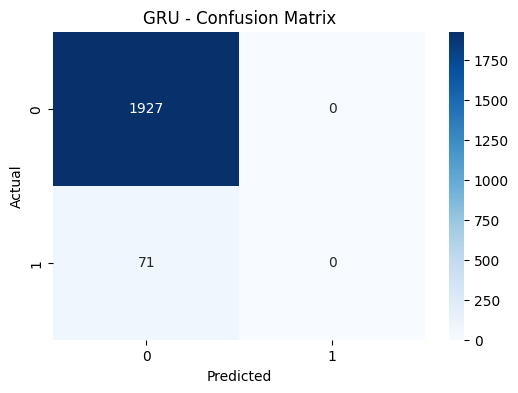

In [67]:
cm_gru = confusion_matrix(
    y_lstm_test,
    y_pred_gru
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU - Confusion Matrix")

plt.show()

In [68]:
results.append({
    "Model": "GRU",
    "Accuracy": gru_accuracy,
    "Precision": gru_precision,
    "Recall": gru_recall,
    "F1 Score": gru_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.960500,0.466667,0.089744,0.150538
1,Decision Tree,0.967000,0.642857,0.346154,0.450000
2,Random Forest,0.974000,0.782609,0.461538,0.580645
3,XGBoost,0.973500,0.777778,0.448718,0.569106
4,LSTM,0.964464,0.000000,0.000000,0.000000
5,GRU,0.964464,0.000000,0.000000,0.000000


In [69]:
from tensorflow.keras.layers import (
    Input,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model

In [74]:
from tensorflow.keras.layers import (
    Input,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

In [75]:
# Input: 10 time steps × 9 sensor features
input_layer = Input(
    shape=(
        X_lstm_train_scaled.shape[1],
        X_lstm_train_scaled.shape[2]
    )
)

# Project 9 input features into 64-dimensional representation
x = Dense(64)(input_layer)

# Multi-Head Self Attention
attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)(
    x,
    x
)

# Residual connection + normalization
x = LayerNormalization()(
    x + attention_output
)

# Feed-forward network
feed_forward = Dense(
    64,
    activation="relu"
)(x)

feed_forward = Dropout(0.2)(feed_forward)

# Second residual connection + normalization
x = LayerNormalization()(
    x + feed_forward
)

# Convert sequence into one vector
x = GlobalAveragePooling1D()(x)

# Classification layer
x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(0.2)(x)

# Failure probability
output_layer = Dense(
    1,
    activation="sigmoid"
)(x)

# Create model
transformer_model = Model(
    inputs=input_layer,
    outputs=output_layer
)

# Compile
transformer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 10, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10, 64)    │        640 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 10, 64)    │          0 │ dense_8[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 10, 64)    │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
transformer_history = transformer_model.fit(
    X_lstm_train_scaled,
    y_lstm_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9448 - loss: 0.2060 - val_accuracy: 0.9543 - val_loss: 0.1878
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9615 - loss: 0.1722 - val_accuracy: 0.9543 - val_loss: 0.1893
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9615 - loss: 0.1669 - val_accuracy: 0.9543 - val_loss: 0.2041
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9615 - loss: 0.1692 - val_accuracy: 0.9543 - val_loss: 0.1989
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9615 - loss: 0.1671 - val_accuracy: 0.9543 - val_loss: 0.1875
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9615 - loss: 0.1651 - val_accuracy: 0.9543 - val_loss: 0.1864
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9615 - loss: 0.1667 - val_accuracy: 0.9543 - val_loss: 0.1919
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9615 - loss: 0.1641 - val_acc

In [77]:
transformer_loss, transformer_accuracy = transformer_model.evaluate(
    X_lstm_test_scaled,
    y_lstm_test,
    verbose=0
)

print("Transformer Results")
print("--------------------------------")
print("Test Loss     :", transformer_loss)
print("Test Accuracy :", transformer_accuracy)

Transformer Results
--------------------------------
Test Loss     : 0.15628743171691895
Test Accuracy : 0.9644644856452942


In [78]:
y_prob_transformer = transformer_model.predict(
    X_lstm_test_scaled
).flatten()

y_pred_transformer = (
    y_prob_transformer >= 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [79]:
transformer_precision = precision_score(
    y_lstm_test,
    y_pred_transformer
)

transformer_recall = recall_score(
    y_lstm_test,
    y_pred_transformer
)

transformer_f1 = f1_score(
    y_lstm_test,
    y_pred_transformer
)

print("Transformer Classification Results")
print("--------------------------------")
print("Accuracy :", transformer_accuracy)
print("Precision:", transformer_precision)
print("Recall   :", transformer_recall)
print("F1 Score :", transformer_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_lstm_test,
        y_pred_transformer
    )
)

Transformer Classification Results
--------------------------------
Accuracy : 0.9644644856452942
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1927
           1       0.00      0.00      0.00        71

    accuracy                           0.96      1998
   macro avg       0.48      0.50      0.49      1998
weighted avg       0.93      0.96      0.95      1998



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

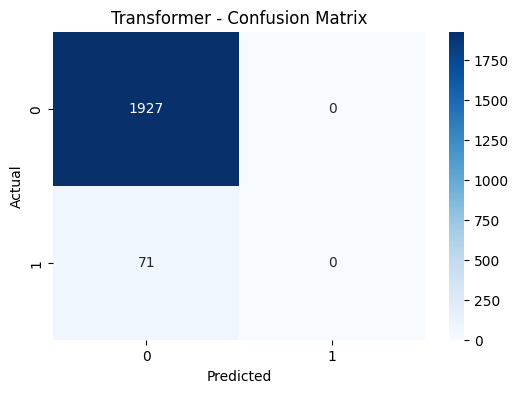

In [80]:
cm_transformer = confusion_matrix(
    y_lstm_test,
    y_pred_transformer
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transformer - Confusion Matrix")

plt.show()

In [81]:
results.append({
    "Model": "Transformer",
    "Accuracy": transformer_accuracy,
    "Precision": transformer_precision,
    "Recall": transformer_recall,
    "F1 Score": transformer_f1
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.960500,0.466667,0.089744,0.150538
1,Decision Tree,0.967000,0.642857,0.346154,0.450000
2,Random Forest,0.974000,0.782609,0.461538,0.580645
3,XGBoost,0.973500,0.777778,0.448718,0.569106
4,LSTM,0.964464,0.000000,0.000000,0.000000
5,GRU,0.964464,0.000000,0.000000,0.000000
6,Transformer,0.964464,0.000000,0.000000,0.000000


In [82]:
results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.974000,0.782609,0.461538,0.580645
1,XGBoost,0.973500,0.777778,0.448718,0.569106
2,Decision Tree,0.967000,0.642857,0.346154,0.450000
3,Logistic Regression,0.960500,0.466667,0.089744,0.150538
4,LSTM,0.964464,0.000000,0.000000,0.000000
5,GRU,0.964464,0.000000,0.000000,0.000000
6,Transformer,0.964464,0.000000,0.000000,0.000000


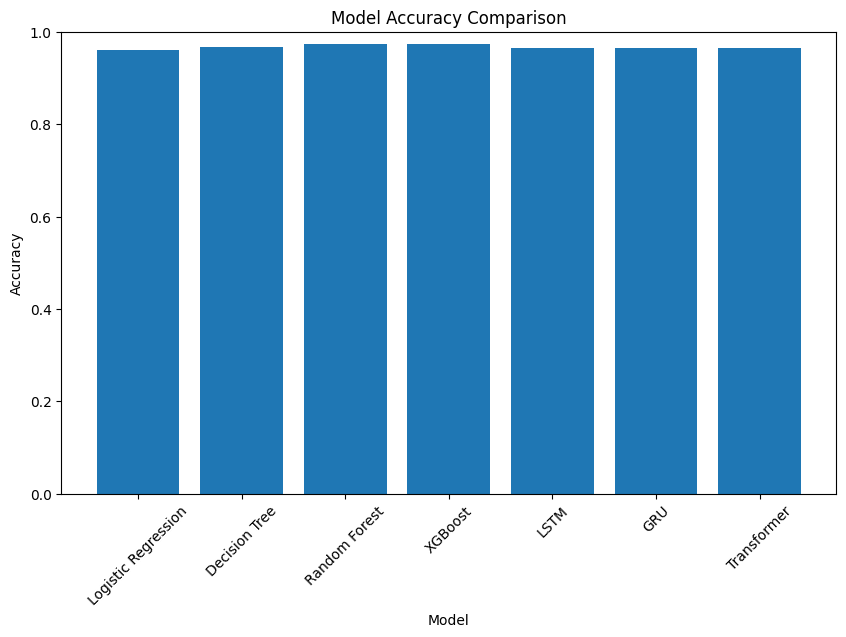

In [83]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

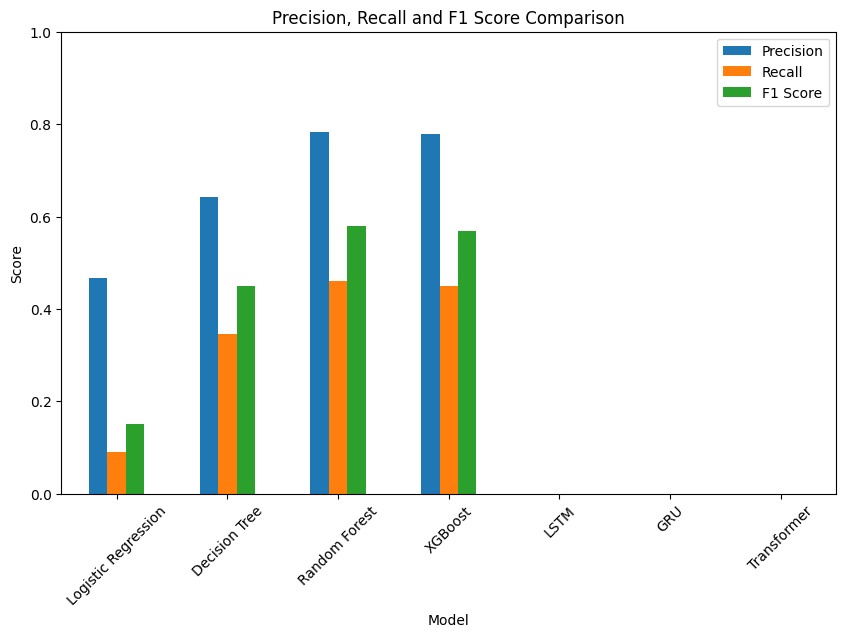

In [84]:
results_plot = results_df.set_index("Model")[
    ["Precision", "Recall", "F1 Score"]
]

results_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score Comparison")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.legend()
plt.show()

In [85]:
results_df.to_csv(
    "vehicle_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [86]:
def predict_vehicle_health(
    engine_temperature,
    rpm,
    oil_pressure,
    vibration,
    battery_voltage,
    coolant_temperature,
    fuel_consumption,
    vehicle_speed,
    operating_hours
):

    # Create input DataFrame
    input_data = pd.DataFrame([[
        engine_temperature,
        rpm,
        oil_pressure,
        vibration,
        battery_voltage,
        coolant_temperature,
        fuel_consumption,
        vehicle_speed,
        operating_hours
    ]], columns=features)

    # Failure probability
    failure_probability = xgb_model.predict_proba(
        input_data
    )[0][1]

    # Convert failure probability to percentage
    failure_percentage = failure_probability * 100

    # Vehicle health score
    health_score = 100 - failure_percentage

    # Determine status
    if health_score >= 80:
        status = "HEALTHY"
    elif health_score >= 60:
        status = "WARNING"
    else:
        status = "CRITICAL"

    return failure_percentage, health_score, status

In [87]:
failure_probability, health_score, status = predict_vehicle_health(
    engine_temperature=110,
    rpm=3800,
    oil_pressure=25,
    vibration=5.5,
    battery_voltage=11.2,
    coolant_temperature=105,
    fuel_consumption=12,
    vehicle_speed=70,
    operating_hours=4200
)

print("Vehicle Health Monitoring System")
print("--------------------------------")
print(f"Failure Probability : {failure_probability:.2f}%")
print(f"Vehicle Health      : {health_score:.2f}%")
print(f"Status              : {status}")

Vehicle Health Monitoring System
--------------------------------
Failure Probability : 98.39%
Vehicle Health      : 1.61%
Status              : CRITICAL


In [88]:
if status == "HEALTHY":
    maintenance_alert = "No immediate maintenance required."

elif status == "WARNING":
    maintenance_alert = "Maintenance inspection recommended soon."

else:
    maintenance_alert = "Immediate maintenance inspection required."

print("Maintenance Alert:", maintenance_alert)

Maintenance Alert: Immediate maintenance inspection required.


In [89]:
print("==========================================")
print("       VEHICLE HEALTH MONITORING")
print("==========================================")

print(f"Vehicle Health     : {health_score:.2f}%")
print(f"Failure Probability: {failure_probability:.2f}%")
print(f"Status             : {status}")
print(f"Maintenance Alert  : {maintenance_alert}")

print("==========================================")

       VEHICLE HEALTH MONITORING
Vehicle Health     : 1.61%
Failure Probability: 98.39%
Status             : CRITICAL
Maintenance Alert  : Immediate maintenance inspection required.


In [90]:
def get_contributing_factors():

    top_factors = xgb_importance.head(3)

    factors = []

    for _, row in top_factors.iterrows():
        factors.append(row["Feature"])

    return factors

In [91]:
major_factors = get_contributing_factors()

print("Major Contributing Factors:")
for i, factor in enumerate(major_factors, start=1):
    print(f"{i}. {factor}")

Major Contributing Factors:
1. Vibration
2. Engine_Temperature
3. Coolant_Temperature


In [92]:
factor_names = {
    "Engine_Temperature": "High engine temperature",
    "RPM": "High engine RPM",
    "Oil_Pressure": "Abnormal oil pressure",
    "Vibration": "High vibration",
    "Battery_Voltage": "Low battery voltage",
    "Coolant_Temperature": "High coolant temperature",
    "Fuel_Consumption": "High fuel consumption",
    "Vehicle_Speed": "High vehicle speed",
    "Operating_Hours": "High operating hours"
}

In [93]:
print("==============================================")
print("       AI VEHICLE HEALTH MONITORING SYSTEM")
print("==============================================")

print(f"Vehicle Health      : {health_score:.2f}%")
print(f"Failure Probability : {failure_probability:.2f}%")
print(f"Status              : {status}")

print("\nMajor Contributing Factors:")

for i, factor in enumerate(major_factors, start=1):
    print(f"{i}. {factor_names[factor]}")

print("\nMaintenance Alert:")
print(maintenance_alert)

print("==============================================")

       AI VEHICLE HEALTH MONITORING SYSTEM
Vehicle Health      : 1.61%
Failure Probability : 98.39%
Status              : CRITICAL

Major Contributing Factors:
1. High vibration
2. High engine temperature
3. High coolant temperature

Maintenance Alert:
Immediate maintenance inspection required.
